In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sys
from sklearn.metrics import mean_squared_error

import warnings 
warnings.filterwarnings('ignore') 

sys.path.append("../../")
import stan

## Loading ST dataset
We use a Visium spatial transcriptomics dataset of the human lymph node, which is publicly available from the 10x genomics website. For first time use, the dataset will be downloaded to the directory data/V1_Human_Lymph_Node by default.

In [2]:
adata = sc.datasets.visium_sge(sample_id="V1_Human_Lymph_Node")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 4035 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

We will assign germinal centers and cell type to each spot. The files can be downloaded from [here](https://raw.githubusercontent.com/vitkl/cell2location_paper/1c645a0519f8f27ecef18468cf339d35d99f42e7/notebooks/selected_results/lymph_nodes_analysis/CoLocationModelNB4V2_34clusters_4039locations_10241genes_input_inferred_V4_batch1024_l2_0001_n_comb50_5_cps5_fpc3_alpha001/W_cell_density.csv) and [here](https://raw.githubusercontent.com/vitkl/cell2location_paper/1c645a0519f8f27ecef18468cf339d35d99f42e7/notebooks/selected_results/lymph_nodes_analysis/CoLocationModelNB4V2_34clusters_4039locations_10241genes_input_inferred_V4_batch1024_l2_0001_n_comb50_5_cps5_fpc3_alpha001/manual_GC_annot.csv). We have provided the files in the repository too.

In [3]:
celltypes = pd.read_csv("W_cell_density.csv", index_col=0)
gc_annotation = pd.read_csv("manual_GC_annot.csv", index_col=0).fillna(0).replace("GC", 1)

obs_names = np.intersect1d(celltypes.index, adata.obs_names)
adata = adata[obs_names]
celltypes = celltypes.loc[obs_names]
gc_annotation = gc_annotation.loc[obs_names]
adata.obsm['celltype'] = celltypes
adata.obsm['celltype'].columns = [x.replace('mean_spot_factors','') for x in adata.obsm['celltype'].columns]
adata.obsm['celltype_raw'] = adata.obsm['celltype'].copy()
adata.obsm['celltype'] = adata.obsm['celltype'].divide(adata.obsm['celltype'].sum(axis=1), axis=0)
adata.obs['germinal_center'] = gc_annotation
adata.obs['germinal_center'] = adata.obs['germinal_center'].map({0: "Other", 1: "GC"})

We perform some basic filtering of genes and spots.

In [4]:
sc.pp.filter_genes(adata, min_cells=5)
sc.pp.filter_cells(adata, min_counts=5000)

Write the processed data to file.

In [5]:
!mkdir results_lymphnode/
adata.write("results_lymphnode/lymphnode.h5ad")

mkdir: results_lymphnode/: File exists


## Loading the gene-TF prior matrix

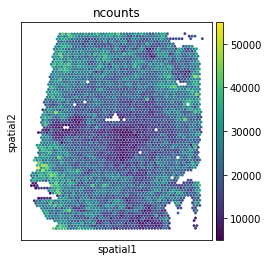

<Axes: >

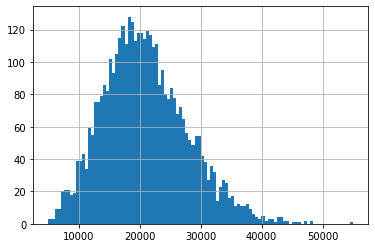

In [6]:
adata.layers['raw'] = adata.X
adata.obs['ncounts'] = adata.to_df('raw').T.sum()
sc.pl.spatial(adata, color='ncounts', size=1.5, alpha_img=0)
adata.obs['ncounts'].hist(bins=100)

We obtain a gene set resource comprising TF–target gene priors from [hTFtarget](https://guolab.wchscu.cn/hTFtarget/#!/), and retain only those TFs that were identified in the Human Transcription Factor database [(humantfs)](https://www.cell.com/cell/fulltext/S0092-8674(18)30106-5) to generate the TF–target gene prior matrix. For first time use, the prior information will be downloaded to the directory `data/gene_tf` by default.

For the ST dataset, the TF–target gene prior matrix (referred to as $D$) and the spot-level gene expression matrix (referred to as $Y$) undergo a sequential filtering process:
- In $Y$, genes expressed in less than 20% of the spots are removed. 
- Only mutual genes present in both matrices are retained. 
- In $D$, genes associated with less than 5 remaining TFs are removed, and TFs associated with fewer than 10 remaining genes are removed.

All paramters are tunable. The filtered TF–target gene prior matrix is stored in `adata.varm['gene_tf']`.

In [7]:
adata = stan.add_gene_tf_matrix(adata,
                                min_cells_proportion = 0.2,
                                min_tfs_per_gene= 5,
                                min_genes_per_tf= 10,
                                gene_tf_source="hTFtarget",
                                tf_list="humantfs",
                                source_dir="../data/gene_tf/")

We check the sizes of the matrices after filtering.

In [8]:
D = adata.varm['gene_tf']
print('gene-TF matrix: {} x {}'.format(D.shape[0], D.shape[1]))
print('min tfs associated with each gene: {}'.format(D.T.abs().sum().min()))
print('min genes associated with each tf: {}'.format(D.abs().sum().min()))

gene-TF matrix: 8932 x 234
min tfs associated with each gene: 5
min genes associated with each tf: 10


In [9]:
Y = adata.to_df()
print('gene-cell matrix: {} x {}'.format(Y.shape[1], Y.shape[0]))
print('min cells associated with each gene: {}'.format((Y>0).sum().min()))
print('min genes associated with each cell: {}'.format((Y>0).T.sum().min()))

gene-cell matrix: 8932 x 3989
min cells associated with each gene: 798
min genes associated with each cell: 2132


## Computing the spatially dependent kernel
A Gaussian kernel matrix $K$,  stored in `adata.obsm['kernel']`, is computed based on the spatial and morphological information of the spot and a neighborhood of a square.
-  `windowsize`: length of the half side of the square (unit: pixel).
- `bandwidth`: band width using the computation of $K$.
- `im_feats_weight`: morphological info to spatial info ratio.
- `n`: the top $n$ singular values of $A$ in SVD.

All paramters are tunable. The spatial and morphological information is stored in `adata.obsm['spatial']` and `adata.obsm['pixel']` respectively, and are normalized to have zero mean and unit variance for each component.

In [10]:
stan.pixel_intensity(adata, windowsize=25)
stan.make_kernel(adata, n=250, im_feats_weight=0.05, bandwidth=0.2)

Time elapsed: 0.24 seconds
Time elapsed: 5.96 seconds


We normalize each spot by total counts over all genes, and then square root transform the total count to stabilize the variance.

In [11]:
sc.pp.normalize_total(adata)
adata.layers['scaled'] = np.sqrt(adata.to_df())

## TF activity inference

In [12]:
stan.assign_folds(adata, n_folds=10, random_seed=0)

### STAN

In [13]:
stan_model = stan.Stan(adata, layer='scaled')
stan_model.fit(n_steps=5, stages=1,
              grid_search_params={'lam1':[1e-4, 1e4], 'lam2':[1e-4, 1e4]})

Time elapsed: 126.28 seconds


Evaluate the cross validation performance using Pearsonr correlation coefficient.

In [14]:
cor, gene_cor = stan_model.evaluate(fold=-1)
adata.obs['pred_cor_stan'] = cor
adata.var['pred_cor_stan'] = gene_cor

print(stan_model.params)
print("Spot-wise correlation:" + str(round(np.nanmedian(cor), 4)))
print("Gene-wise correlation: " + str(round(np.nanmedian(gene_cor), 4)))

{'lam1': 10000.0, 'lam2': 0.0001}
Spot-wise correlation:0.2317
Gene-wise correlation: 0.0921


Evaluate the validation performance using mean squared error.

In [15]:
Y = adata.varm['gene_tf'].dot(stan_model.W_concat)
mean_squared_error(Y, adata.to_df('scaled').T)

1.0439224714002515

Store the inferred TF activity matrix in adata.obsm['tfa_stan'].

In [16]:
adata.obsm['tfa_stan'] = pd.DataFrame(
    stan_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

### Ridge regression (baseline)

In [17]:
ridge_model = stan.Ridge(adata, layer='scaled')
ridge_model.fit(n_steps=5, stages=1,
                grid_search_params={'lam':[1e-4, 1e4]})

Time elapsed: 29.25 seconds


Evaluate the cross validation performance using Pearsonr correlation coefficient.

In [18]:
cor, gene_cor = ridge_model.evaluate(fold=-1)
adata.obs['pred_cor_ridge'] = cor
adata.var['pred_cor_ridge'] = gene_cor

print(ridge_model.params)
print("Sample Cor:" + str(round(np.nanmedian(cor), 4)))
print(" Gene Cor: " + str(round(np.nanmedian(gene_cor), 4)))

{'lam': 0.0001}
Sample Cor:0.2237
 Gene Cor: 0.0619


Evaluate the validation performance using mean squared error.

In [19]:
Y = adata.varm['gene_tf'].dot(ridge_model.W_concat)
mean_squared_error(Y, adata.to_df('scaled').T)

1.0354316848848208

Store the inferred TF activity matrix in `adata.obsm['tfa_ridge']`.

In [20]:
adata.obsm['tfa_ridge'] = pd.DataFrame(
    ridge_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

## Writing the results to files

In [23]:
adata.write("results_lymphnode/lymphnode_stan.h5ad")